# Problem 6 - Phase Identification(2)

## Agenda
- Problem Description
- Problem Implementation
- Wrap-Up

## Problem Description
- <b>Consider $N$ customers whose connection phase assumes one out of three possible labels $a$, $b$, or $c$ and estimate the correct customer-to-label assignment based on $M$ readings whose per-phase values are a function of the corresponding phase-connected individual customer reading.

Considered network
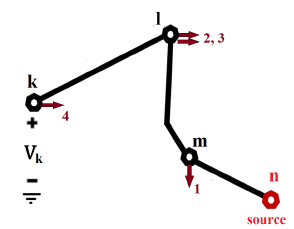

<b>Import Python Libraries

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Parameters

In [76]:
cosPhi=0.95
time=48
m=12
netFactor=0.25
noiseFactor=0.00

<b>Initial data

In [77]:
#Consumption dataset
s=  [[0.0450,    0.0150,    0.0470,    0.0330],
     [0.0250,    0.0150,    0.2480,    0.0330],
     [0.0970,    0.0250,    0.3940,    0.0330],
     [0.0700,    0.0490,    0.0200,    0.4850],
     [0.1250,    0.0460,    0.0160,    0.1430],
     [0.2900,    0.0270,    0.0160,    0.0470],
     [0.2590,    0.0150,    0.0170,    0.0200],
     [0.2590,    0.0160,    0.0280,    0.0160],
     [0.4420,    0.0160,    0.0500,    0.0170],
     [0.2010,    0.0230,    0.0460,    0.0160],
     [0.2060,    0.0490,    0.0220,    0.0240],
     [0.1300,    0.0470,    0.0160,    0.0490],
     [0.0460,    0.0260,    0.0170,    0.0480]]
s = np.array(s)

#topology
topo=[[1, 2],[2,3],[3,4]]
nBUS=np.max(topo)

#Impedance
z=np.multiply([complex(0.1,0.05),complex(0.15,0.07),complex(0.2,0.1)],netFactor)

vr=1 #Reference voltage
el=1
ni=20 #Iterations for the Power Flow




<b>Power Flow Function

In [78]:
def pf3ph(t,z,si,vr,el,ni,al):
    #Matrices creation
    t=np.array(t)
    p=t[:,0]
    f=t[:,1]
    w=len(p)+1
    vp=np.zeros((nBUS-1,w), dtype=complex)
    vn=np.zeros((nBUS-1,w), dtype=complex)
    vp[0,0:w]=vr
    
    for h in range (2,nBUS):
        vp[h-1,:]=vp[h-2,:]*al  #Create a three phase system of voltages
                                #Voltages will be the same in all BUS

    va=vp-vn                                                      #Auxiliar voltage
    ia=np.conj(np.divide(np.multiply(si,np.abs(va)**el),va))      #Auxiliar current 
    
    for it in range(ni):                                          #Iterations of Power Flow
        va=vp-vn
        ip=np.conj(np.divide(np.multiply(si,np.abs(va)**el),va))  #Phase current 
        inn=-np.sum(ip,0)                                         #Neutral current 
        for k in range(w-1,0,-1):                                 #Backward Cycle
            n=f[k-1]
            m=p[k-1]
            ip[:,m-1]=ip[:,m-1]+ip[:,n-1]                         #Phase Current
            inn=-np.sum(ip,0)                                     #Neutral Current

        eps= np.linalg.norm(np.max(np.abs(ia-ip),0))              #Error, comparing the new currents and the old ones (previous iteration)

        if eps>1e-4:
            ia=ip
            mvp=0
            mvn=0
            eps=np.inf
        else:                       #If the error is lower than the limit, we can return the results 
            mvp=(vp-vn)             #Phase Voltages to return
            mvn=vn[0,:]             #Neutral Voltage to return
#            return mvp, mvn, eps, ip, inn;
            return mvp;
        for k in range (w-1):                     #Forward Cycle
            n=f[k]                                
            m=p[k]
            vn[:,n-1]=vn[:,m-1]-z[k]*inn[n-1]     #Neutral Voltage 
            vp[:,n-1]=vp[:,m-1]-z[k]*ip[:,n-1]    #Phase Voltage
        ia=ip             #Save the current of previous iteration


<b> Compute the values of voltages obtained by PMUs

In [79]:
#Creation of Matrices
al=np.exp(np.multiply(np.multiply(complex(0,-1),2/3),np.pi)) #Phase Angle
Y=np.zeros((3*m), dtype=complex)
X=np.zeros((3*m,m), dtype=complex)
v=np.zeros((m,3))
dv_abs=np.zeros((m,3))


for i in range(m):
    si=[[0, 0, s[i,2], 0],[0, 0, s[i,1], 0],[0, s[i,0],  0, s[i,3]]] #Connection of consumers by
                                                                     #node and by phase
                                                                     #Consumer 1 (s[i,0]) is 
                                                                     #connected to Bus 2 in Phase 3
    mvp=pf3ph(topo,z,si,vr,el,ni,al)
    noise=1+noiseFactor*np.random.randn(3)
    mvp[:,3]=np.multiply(mvp[:,3],noise)                       #Add noise to the voltages
    Y[3*(i):3*(i)+3]=mvp[:,3]                                  #Save the voltages in matrix Y
    dv_abs[i,:]=vr-np.abs(mvp[:,3])                            #Volage variations (only to plot)

Volt=np.reshape(Y,(m,3))   

print ('The voltages measured in the PMUs are:\n',Volt)

The voltages measured in the PMUs are:
 [[ 0.99866484-0.00476962j -0.49831414-0.86835917j -0.49392011+0.85964588j]
 [ 0.97290228-0.01601085j -0.51139766-0.87380016j -0.50744349+0.85456696j]
 [ 0.95608633-0.02441701j -0.51885398-0.87750207j -0.51325967+0.84910673j]
 [ 1.04767033-0.03551787j -0.45091668-0.89757332j -0.40102796+0.79332501j]
 [ 1.01576499-0.00999985j -0.48302166-0.87236861j -0.46567302+0.84426734j]
 [ 1.00968654-0.00695356j -0.48918564-0.87063669j -0.47774451+0.85167455j]
 [ 1.00602188-0.005418j   -0.49284148-0.869901j   -0.48483326+0.85566688j]
 [ 1.00423842-0.00571336j -0.4939299 -0.86980129j -0.48633757+0.85598497j]
 [ 1.00578779-0.00995392j -0.4910006 -0.87340185j -0.4790803 +0.84942259j]
 [ 1.0006834 -0.00538471j -0.49631931-0.86845387j -0.49010362+0.8577634j ]
 [ 1.00475844-0.00282624j -0.4936193 -0.86480633j -0.48660002+0.8589564j ]
 [ 1.00631448-0.00319825j -0.49244873-0.86549546j -0.48460471+0.85781421j]]


<b> Sum of Impedences
    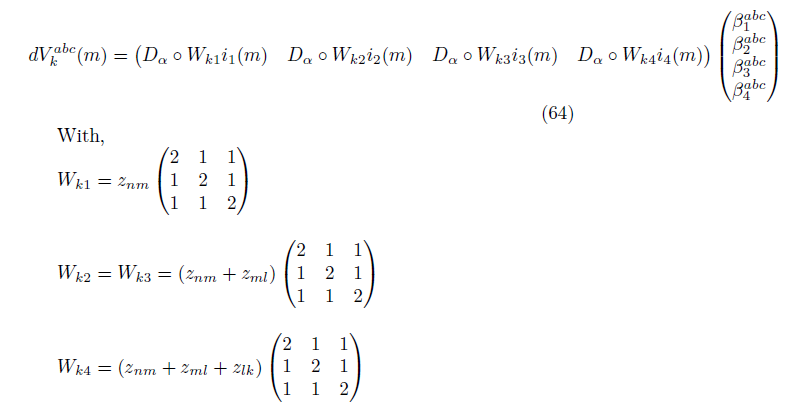

In [80]:
#The value of Z is the multiplication between D and W but not considering the values of z_nm;z_ml and zlk
Z=[[2, al, al**2],[1, 2*al, al**2],[1, al, 2*al**2]]


<b>Complex Expansion
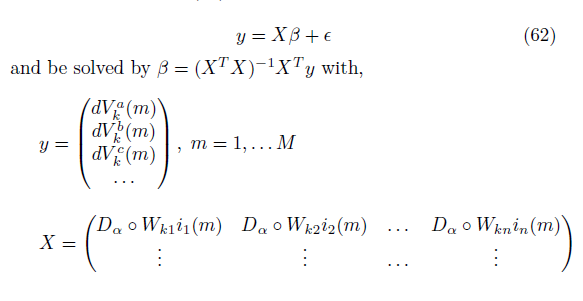

In [81]:
# Matrices Creation
vz = np.zeros(3*m, dtype=complex)
vz_abs = np.zeros(3*m, dtype=complex)

# Compute dVk for each time period m   
for i in range(m):
    # PMU (complex voltages)
    vz[3*i:3*i+3] = vr*np.array([1, al, al**2]) - Y[3*i:3*i+3]

    # RTU (only magnitudes)
    vz_abs[3*i:3*i+3] = (vr - np.abs(Y[3*i:3*i+3])) * np.array([1, al, al**2])


X = np.zeros((3*m, 12), dtype=complex)

for i in range(m):
    X_block = np.zeros((3, 12), dtype=complex)

    for c in range(4): 
        # Each consumer contributes a 3×3 block = Z * s[i,c]
        Z = np.array([[2, al, al**2],
              [1, 2*al, al**2],
              [1, al, 2*al**2]], dtype=complex)

        X_block[:, 3*c:3*(c+1)] = Z * s[i, c]

    X[3*i:3*i+3, :] = X_block


# Betas with PMUs info
Bpmu, *_ = np.linalg.lstsq(X, vz, rcond=None)

# Betas with RTUs info
Brtu, *_ = np.linalg.lstsq(X, vz_abs, rcond=None)


BBpmu = Bpmu.reshape(4, 3)
BBrtu = Brtu.reshape(4, 3)


def to_binary_labels(B):
    BB = np.zeros_like(B, dtype=int)
    for i in range(B.shape[0]):
        k = np.argmax(np.real(B[i, :]))   
        BB[i, k] = 1
    return BB

BBpmu_bin = to_binary_labels(BBpmu)
BBrtu_bin = to_binary_labels(BBrtu)



print('Betas (complex) considering information from PMUs:\n', Bpmu, '\n')
print('Betas (complex) considering information from RTUs:\n', Brtu, '\n')

print('Betas organized (customer × phase) PMUs:\n', BBpmu, '\n')
print('Betas organized (customer × phase) RTUs:\n', BBrtu, '\n')

print('Binary phase labels (PMUs):\n', BBpmu_bin, '\n')
print('Binary phase labels (RTUs):\n', BBrtu_bin, '\n')


Betas (complex) considering information from PMUs:
 [-3.13266200e-05+6.79589395e-05j -1.06608093e-05+2.18806848e-05j
  2.51598753e-02+1.21686542e-02j -1.87707107e-04+4.01524765e-04j
  6.25000727e-02+3.00103847e-02j -3.48618490e-03+7.77170725e-03j
  6.31511373e-02+2.86031037e-02j  3.23783029e-05-6.78030351e-05j
 -2.36388641e-04+4.86241992e-04j  1.68250058e-05-3.56869990e-05j
 -9.72493160e-05+1.93911431e-04j  1.15654803e-01+4.80622739e-02j] 

Betas (complex) considering information from RTUs:
 [-0.01139912-0.01138399j  0.00168309+0.0159158j   0.03454583-0.00453181j
  0.00321253+0.0430265j   0.09481318-0.0112951j  -0.02939363-0.0317314j
  0.08601069-0.01043496j -0.02709938-0.02874752j  0.00302374+0.03918248j
 -0.04943624-0.05376477j  0.00078745+0.07116277j  0.15599298-0.017398j  ] 

Betas organized (customer × phase) PMUs:
 [[-3.13266200e-05+6.79589395e-05j -1.06608093e-05+2.18806848e-05j
   2.51598753e-02+1.21686542e-02j]
 [-1.87707107e-04+4.01524765e-04j  6.25000727e-02+3.00103847e-02j


<b>Graphics

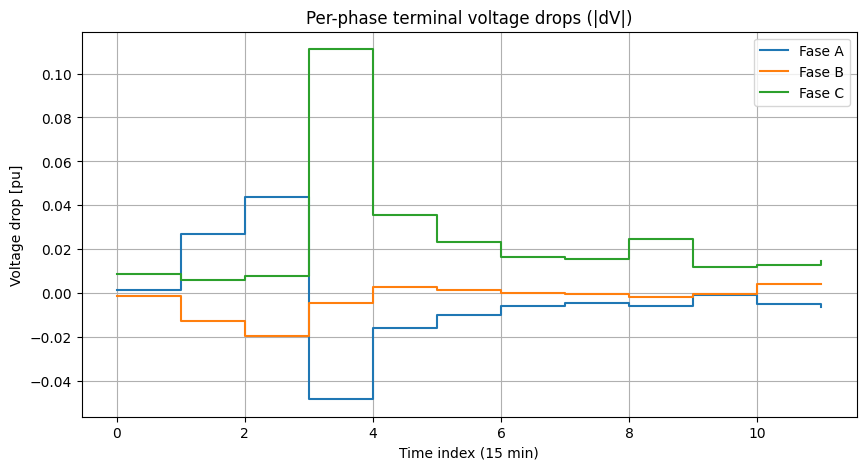

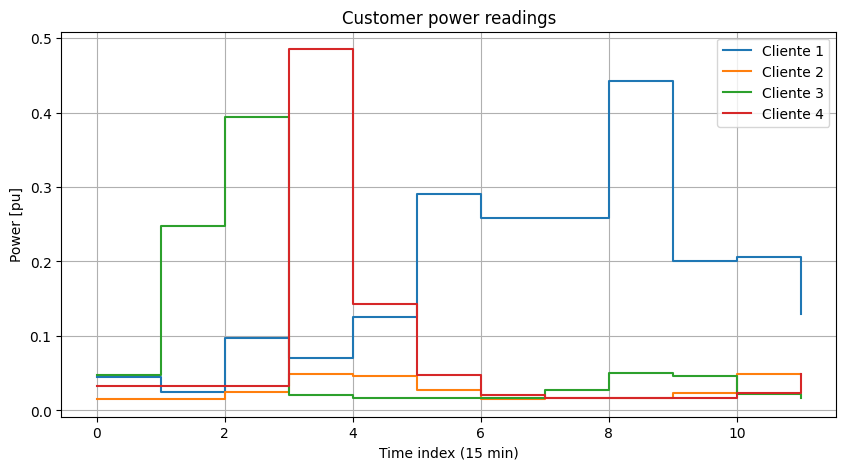

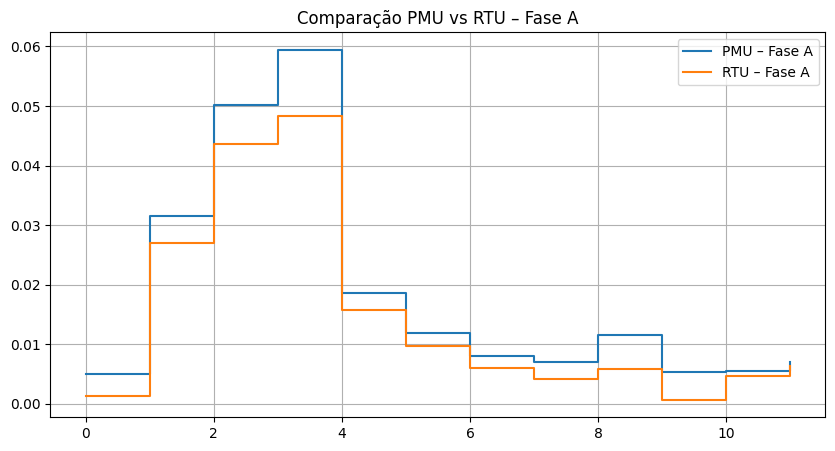

In [82]:
m_pf = dv_abs.shape[0]  
x = np.arange(m_pf)



plt.figure(figsize=(10,5))

plt.step(x, dv_abs[:,0], where='post', label='Fase A')
plt.step(x, dv_abs[:,1], where='post', label='Fase B')
plt.step(x, dv_abs[:,2], where='post', label='Fase C')

plt.title('Per-phase terminal voltage drops (|dV|)')
plt.xlabel('Time index (15 min)')
plt.ylabel('Voltage drop [pu]')
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10,5))

plt.step(x, s[:m_pf,0], where='post', label='Cliente 1')
plt.step(x, s[:m_pf,1], where='post', label='Cliente 2')
plt.step(x, s[:m_pf,2], where='post', label='Cliente 3')
plt.step(x, s[:m_pf,3], where='post', label='Cliente 4')

plt.title('Customer power readings')
plt.xlabel('Time index (15 min)')
plt.ylabel('Power [pu]')
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10,5))
plt.step(x, np.abs(vz[0::3]), where='post', label='PMU – Fase A')
plt.step(x, np.abs(vz_abs[0::3]), where='post', label='RTU – Fase A')
plt.title('Comparação PMU vs RTU – Fase A')
plt.grid(True)
plt.legend()
plt.show()




=== Estudo de Sensibilidade ao Ruído (Multiplicativo) ===

Ruído = 0.0%  →  Accuracy = 100.0%
Ruído = 1.0%  →  Accuracy = 46.7%
Ruído = 2.0%  →  Accuracy = 36.7%
Ruído = 3.0%  →  Accuracy = 20.0%
Ruído = 4.0%  →  Accuracy = 23.3%
Ruído = 5.0%  →  Accuracy = 13.3%
Ruído = 6.0%  →  Accuracy = 6.7%
Ruído = 7.0%  →  Accuracy = 16.7%
Ruído = 8.0%  →  Accuracy = 0.0%
Ruído = 9.0%  →  Accuracy = 3.3%
Ruído = 10.0%  →  Accuracy = 3.3%
Ruído = 11.0%  →  Accuracy = 6.7%
Ruído = 12.0%  →  Accuracy = 6.7%
Ruído = 13.0%  →  Accuracy = 10.0%
Ruído = 14.0%  →  Accuracy = 0.0%
Ruído = 15.0%  →  Accuracy = 3.3%
Ruído = 16.0%  →  Accuracy = 6.7%
Ruído = 17.0%  →  Accuracy = 6.7%
Ruído = 18.0%  →  Accuracy = 6.7%
Ruído = 19.0%  →  Accuracy = 10.0%
Ruído = 20.0%  →  Accuracy = 3.3%


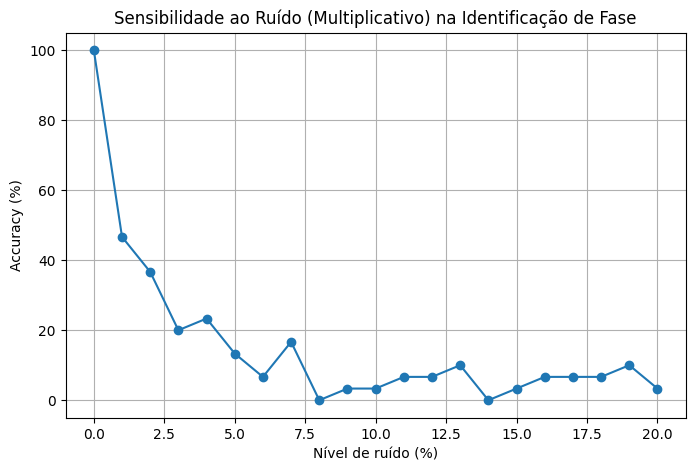


>>> Identificação perfeita até cerca de 0.0% de ruído.



In [83]:
# ============================================================
# ESTUDO DE SENSIBILIDADE AO RUÍDO (MULTIPLICATIVO)
# ============================================================

print("\n=== Estudo de Sensibilidade ao Ruído (Multiplicativo) ===\n")

noise_levels = np.linspace(0, 0.20, 21)   # 0% a 20%
Nsim = 30                                 # simulações por nível
accuracy = np.zeros(len(noise_levels))

# Fases reais dos clientes (A=0, B=1, C=2)
true_labels = np.array([2, 1, 0, 2])

def get_phase_from_beta(B):
    return np.argmax(np.real(B), axis=1)

for idx, nf in enumerate(noise_levels):
    correct = 0

    for _ in range(Nsim):

        # --- REFAZER TODO O PIPELINE PARA ESTE NÍVEL DE RUÍDO ---
        Y_sim = np.zeros(3*m, dtype=complex)

        for i in range(m):
            si = [
                [0, 0, s[i,2], 0],
                [0, 0, s[i,1], 0],
                [0, s[i,0], 0, s[i,3]]
            ]

            mvp = pf3ph(topo, z, si, vr, el, ni, al)

            # aplicar ruído multiplicativo às tensões
            noise = 1 + nf*np.random.randn(3)
            mvp[:, 3] *= noise

            Y_sim[3*i:3*i+3] = mvp[:, 3]

        # --- RECONSTRUIR vz ---
        vz_sim = np.zeros(3*m, dtype=complex)
        for i in range(m):
            vz_sim[3*i:3*i+3] = vr*np.array([1, al, al**2]) - Y_sim[3*i:3*i+3]

        # --- MÍNIMOS QUADRADOS ---
        Bpmu_sim, *_ = np.linalg.lstsq(X, vz_sim, rcond=None)
        BBpmu_sim = Bpmu_sim.reshape(4, 3)

        # --- IDENTIFICAÇÃO ---
        est_labels = get_phase_from_beta(BBpmu_sim)

        if np.array_equal(est_labels, true_labels):
            correct += 1

    accuracy[idx] = correct / Nsim
    print(f"Ruído = {nf*100:.1f}%  →  Accuracy = {accuracy[idx]*100:.1f}%")

# ============================================================
# GRÁFICO FINAL — SENSIBILIDADE AO RUÍDO
# ============================================================

plt.figure(figsize=(8,5))
plt.plot(noise_levels*100, accuracy*100, marker='o')
plt.title("Sensibilidade ao Ruído (Multiplicativo) na Identificação de Fase")
plt.xlabel("Nível de ruído (%)")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

# Resultado final
max_noise = noise_levels[accuracy == 1.0]
if len(max_noise) > 0:
    print(f"\n>>> Identificação perfeita até cerca de {max_noise[-1]*100:.1f}% de ruído.\n")
else:
    print("\n>>> Nenhum nível de ruído manteve 100% de acerto.\n")


In [ ]:
# ============================================================
# ESTUDO: IMPACTO DA POSIÇÃO DO METER NA IDENTIFICAÇÃO DE FASE
# ============================================================

print("\n=== Estudo: impacto da posição do meter na identificação de fase ===\n")

# Fases reais dos clientes (A=0, B=1, C=2)
true_labels = np.array([2, 1, 0, 2])

def get_phase_from_beta(B):
    return np.argmax(np.real(B), axis=1)

# mapeamento: índice da coluna em mvp → nome do nó
meter_positions = {
    1: "m (bus 2)",
    2: "l (bus 3)",
    3: "k (bus 4 - terminal)"
}

for meter_col, meter_name in meter_positions.items():
    print(f"\n--- Meter colocado em {meter_name} ---")

    # --- REFAZER PIPELINE PARA ESTE NÓ ---
    Y_sim = np.zeros(3*m, dtype=complex)

    for i in range(m):
        si = [
            [0, 0, s[i,2], 0],
            [0, 0, s[i,1], 0],
            [0, s[i,0], 0, s[i,3]]
        ]

        mvp = pf3ph(topo, z, si, vr, el, ni, al)

        # tensões medidas no nó escolhido
        V_meter = mvp[:, meter_col]

        Y_sim[3*i:3*i+3] = V_meter

    # --- RECONSTRUIR vz ---
    vz_sim = np.zeros(3*m, dtype=complex)
    for i in range(m):
        vz_sim[3*i:3*i+3] = vr*np.array([1, al, al**2]) - Y_sim[3*i:3*i+3]

    # --- MÍNIMOS QUADRADOS ---
    Bpmu_sim, *_ = np.linalg.lstsq(X, vz_sim, rcond=None)
    BBpmu_sim = Bpmu_sim.reshape(4, 3)

    # --- IDENTIFICAÇÃO ---
    est_labels = get_phase_from_beta(BBpmu_sim)

    print("Fases estimadas:", est_labels)
    print("Fases reais:     ", true_labels)

    if np.array_equal(est_labels, true_labels):
        print("→ ✔ Identificação correta para este nó!")
    else:
        print("→ ✘ Identificação incorreta para este nó.")
